## Black Scholes Option Pricing Model

## Black Scholes Model<a href="#Black-Scholes-Model" class="anchor-link"></a>

The *Black Scholes* model was published in 1973 for non-dividend paying stocks and since then the model has created a revolution in quantitative finance and opened up derivatives pricing paradigm. Black Scholes model is based on number of assumptions about how financial markets operate and those are:

-   Arbitrage Free Markets
-   Frictionless and Continuous Markets
-   Risk Free Rates
-   Log-normally Distributed Price Movements
-   Constant Volatility

These assumptions may not hold true in reality, but are not particularly limiting.


### Black Scholes Formula<a href="#Black-Scholes-Formula" class="anchor-link"></a>

The Black–Scholes equation describes the price of the option over time as:

$$\frac{\partial V}{\partial t} + \frac 1{2}{\sigma^2 S^2}
\frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial
S} - rV = 0 $$

  
Solving the above equation, we know that the value of a call option for a non-dividend paying stock is:  

$$C = SN(d_1) - Ke^{-rt}N(d_2) $$

and, the corresponding put option price is:

$$P = Ke^{-rt}N(-d_2) - SN(-d_1)$$

where,

$$d_1= \frac{1}{\sigma\sqrt{t}}\left[\ln{\left(\frac{S}{K}\right)} +{\left(r +\frac{\sigma^2}{2}\right)}t\right]$$

$$d_2= d_1 - \sigma \sqrt{t}$$

$$N(x)=\frac{1}{\sqrt{2\pi}}\int\limits_{-\infty}^{x}\mathrm
e^{-\frac{1}{2}x^2} dx $$

$S$ is the spot price of the underlying asset  
$K$ is the strike price  
$r$ is the annualized continuous compounded risk free rate  
$\sigma$ is the volatility of returns of the underlying asset  
$t$ is time to maturity (expressed in years)  
$N(x)$ is the standard normal cumulative distribution

### Greeks<a href="#Greeks" class="anchor-link"></a>

| **Description** |                                                                                                       | **Greeks for Call Option**                               | **Greeks for Put Option**                                 |
|:----------------|:------------------------------------------------------------------------------------------------------|:---------------------------------------------------------|:----------------------------------------------------------|
| **Delta**       | $ \frac {\partial V}{\partial S}$ Sensitivity of Value to changes in price                            | $N(d_1)$                                               | $-N(-d_1)$                                              |
| **Gamma**       | $ \frac {\partial ^{2}V}{\partial S^{2}}$ Sensitivity of Delta to changes in price                    | $\frac{N'(d_1)}{S\sigma\sqrt{t}}$                   |                                                           |
| **Vega**        | $ \frac {\partial V}{\partial \sigma}$ Sensitivity of Value to changes in volatility                  | $SN'(d_1)\sqrt{t}$                                    |                                                           |
| **Theta**       | $ \frac {\partial V}{\partial t}$ Sensitivity of Value to changes in time                             | $-\frac{SN'(d_1)\sigma}{2\sqrt{t}}-rKe^{-rt}N(d_2)$ | $-\frac{SN'(d_1)\sigma}{2\sqrt{t}}+rKe^{-rt}N(-d_2)$ |
| **Rho**         | $ \frac {\partial V}{\partial r}$ Sensitivity of Value to changes in risk-free           | $Kte^{-rt}N(d_2)$                                      | $-Kte^{-rt}N(-d_2)$                                     |


### Import Required Libraries<a href="#Import-Required-Libraries" class="anchor-link"></a>

In [2]:
# Importing libraries
import warnings
warnings.filterwarnings('ignore')

# Base libraries
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.stats import norm

# Plotting
import matplotlib.pyplot as plt
from tabulate import tabulate

# Option Strategy plotting
import opstrat as op

# Set max row to 300
pd.set_option('display.max_rows', 300)

In [6]:
class BS:
    """
    This is a class for Options contract for pricing European options on stocks without dividends.
    Attributes: 
        spot (spot price)         : int or float
        strike (Exercise price)       : int or float 
        rate (borrowing rate)         : float
        dte (timesteps)         : int or float [days to expiration in number of years]
        volatility   : float
    """    
    
    def __init__(self, spot: float, strike: float, rate: float, dte: float, volatility: float):
        assert strike > 0 or strike < 0, f"Strike {strike} cannot be zero 0"
        
        self.spot = spot # Spot Price
        self.strike = strike # Option Strike
        self.rate = rate # Interest Rate    
        self.dte = dte # Days To Expiration
        self.volatility = volatility # Volatility
        
        # Utility 
        self._a_ = self.volatility * self.dte**0.5
        
        # if self.strike == 0:
        #     raise ZeroDivisionError('The strike price cannot be zero')
        # else:
        self._d1_ = (np.log(self.spot / self.strike) + (self.rate + (self.volatility**2) / 2) * self.dte) / self._a_
        self._d2_ = self._d1_ - self._a_
        self._b_ = np.e**-(self.rate * self.dte)
        
        
        # The __dict__ attribute Contains all the attributes defined for the object itself. It maps the attribute name to its value.
        for i in ['callPrice', 'putPrice', 'callDelta', 'putDelta', 'callTheta', 'putTheta', 'callRho', 'putRho', 'vega', 'gamma']:
            self.__dict__[i] = None
        
        [self.callPrice, self.putPrice] = self._price
        [self.callDelta, self.putDelta] = self._delta
        [self.callTheta, self.putTheta] = self._theta
        [self.callRho, self.putRho] = self._rho
        self.vega = self._vega
        self.gamma = self._gamma
        
    def __repr__(self):
        return f"Black_Scholes_Object(spot:{self.spot}, strike:{self.strike}, rate:{self.rate}, days_to_expiration(in_years):{self.dte}, volatility:{self.volatility} )"
    
        
    # Option Price    
    @property
    def _price(self):
        """Returns the option price: [Call price, Put price]"""
        if self.volatility == 0 or self.dte == 0:
            call = np.maximum(0.0, self.spot - self.strike)
            put = np.maximum(0.0, self.strike - self.spot)
        else:
            call = self.spot * norm.cdf(self._d1_) - self.strike * np.e**(-self.rate * self.dte) * norm.cdf(self._d2_)
            put = self.strike * np.e**(-self.rate * self.dte) * norm.cdf(-self._d2_) - self.spot * norm.cdf(-self._d1_)
        return [call, put]


    # Option Delta
    @property
    def _delta(self):
        '''Returns the option delta: [Call delta, Put delta]'''
        if self.volatility == 0 or self.dte == 0:
            call = 1.0 if self.spot > self.strike else 0.0
            put = -1.0 if self.spot < self.strike else 0.0
        else:
            call = norm.cdf(self._d1_)
            put = -norm.cdf(-self._d1_)
        return [call, put]


    # Option Gamma
    @property
    def _gamma(self):
        '''Returns the option gamma'''
        return norm.pdf(self._d1_) / (self.spot * self._a_)


    # Option Vega
    @property
    def _vega(self):
        '''Returns the option vega'''
        if self.volatility == 0 or self.dte == 0:
            return 0.0
        else:
            return self.spot * norm.pdf(self._d1_) * self.dte**0.5 / 100


    # Option Theta
    @property
    def _theta(self):
        '''Returns the option theta: [Call theta, Put theta]'''
        call = -self.spot * norm.pdf(self._d1_) * self.volatility / (2 * self.dte**0.5) - self.rate * self.strike * self._b_ * norm.cdf(self._d2_)

        put = -self.spot * norm.pdf(self._d1_) * self.volatility / (2 * self.dte**0.5) + self.rate * self.strike * self._b_ * norm.cdf(-self._d2_)
        return [call / 365, put / 365]


    # Option Rho
    @property
    def _rho(self):
        '''Returns the option rho: [Call rho, Put rho]'''
        call = self.strike * self.dte * self._b_ * norm.cdf(self._d2_) / 100
        put = -self.strike * self.dte * self._b_ * norm.cdf(-self._d2_) / 100

        return [call, put]

    # Implied Vol
    @property
    def _IV(self):
        pass

In [7]:
# Initialize option
option = BS(100,100,0.05,1,0.20)
option

Black_Scholes_Object(spot:100, strike:100, rate:0.05, days_to_expiration(in_years):1, volatility:0.2 )

In [5]:
option.putPrice

5.573526022256971

In [6]:
header = ['Option Price', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho']
table = [[option.callPrice, option.callDelta, option.gamma, option.callTheta, option.vega, option.callRho]]

print(tabulate(table,header))

  Option Price     Delta     Gamma       Theta     Vega       Rho
--------------  --------  --------  ----------  -------  --------
       10.4506  0.636831  0.018762  -0.0175727  0.37524  0.532325


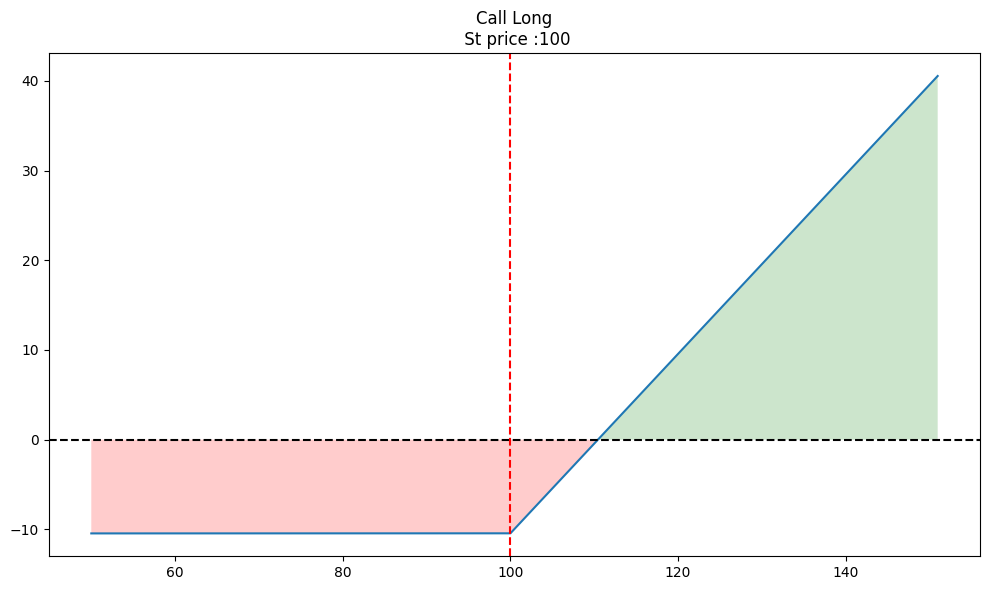

In [7]:
# Plot long call option payoff
op.single_plotter(
    op_type='c',
    spot=option.spot,
    spot_range=50,
    strike=option.strike,
    tr_type='b',
    op_pr=option.callPrice
)

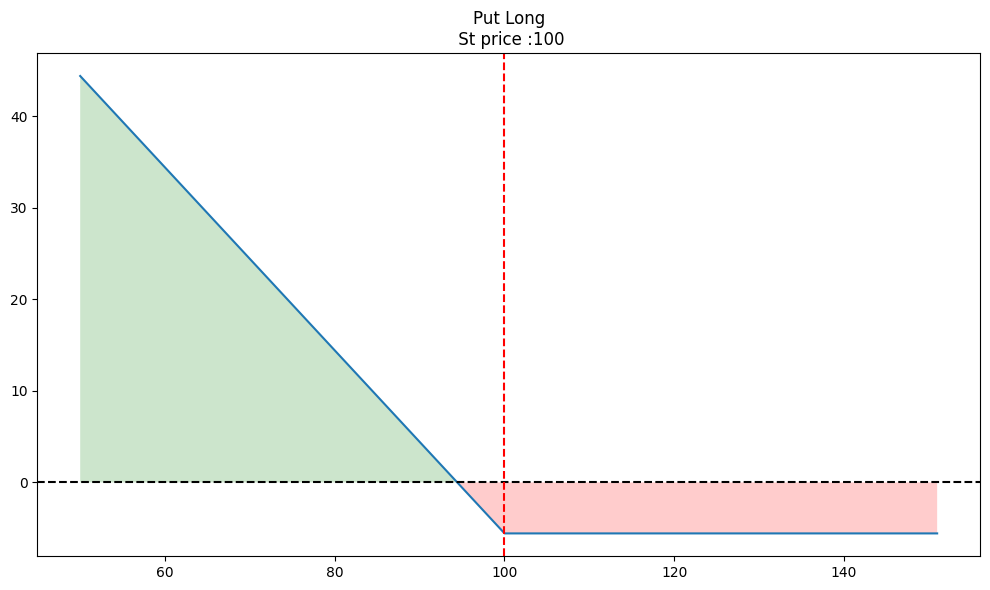

In [8]:
# Plot long put option payoff
op.single_plotter(
    op_type='p',
    spot=option.spot,
    spot_range=50,
    strike=option.strike,
    tr_type='b',
    op_pr=option.putPrice
)

In [9]:
# Short Straddle
op_1 = {'op_type': 'c', 'strike':option.strike, 'tr_type': 's', 'op_pr': option.callPrice}
op_2 = {'op_type': 'p', 'strike':option.strike, 'tr_type': 's', 'op_pr': option.putPrice}

# long Straddle
op_3 = {'op_type': 'c', 'strike':option.strike, 'tr_type': 'b', 'op_pr': option.callPrice}
op_4 = {'op_type': 'p', 'strike':option.strike, 'tr_type': 'b', 'op_pr': option.putPrice}

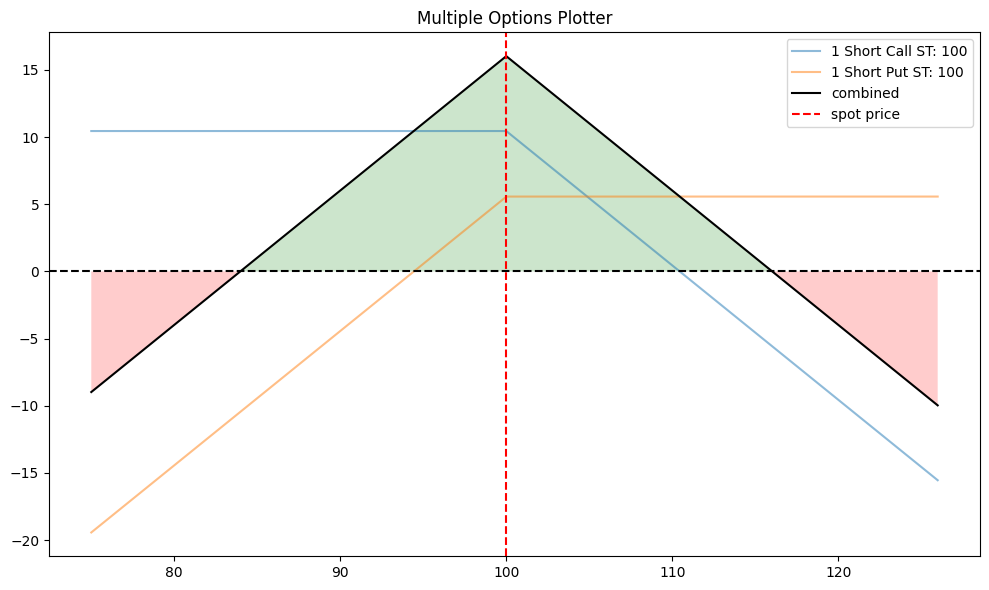

In [10]:
# short straddle plot
op_list = [op_1, op_2]
op.multi_plotter(spot=option.spot, spot_range=25, op_list=op_list)

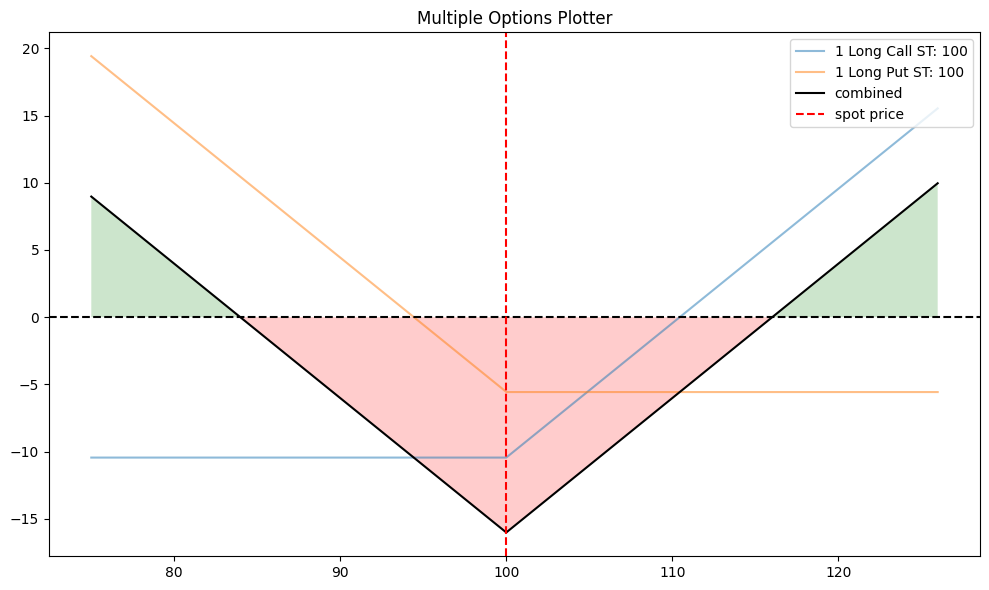

In [11]:
# long straddle plot
op_list2 = [op_3, op_4]
op.multi_plotter(spot=option.spot, spot_range=25, op_list=op_list2)

In [12]:
# Strangle
leg1 = BS(100,110,0.05,1,0.2)
leg2 = BS(100,90,0.05,1,0.2)

op_5 = {'op_type': 'c', 'strike':leg1.strike, 'tr_type': 's', 'op_pr': leg1.callPrice}
op_6 = {'op_type': 'p', 'strike':leg2.strike, 'tr_type': 's', 'op_pr': leg2.putPrice}

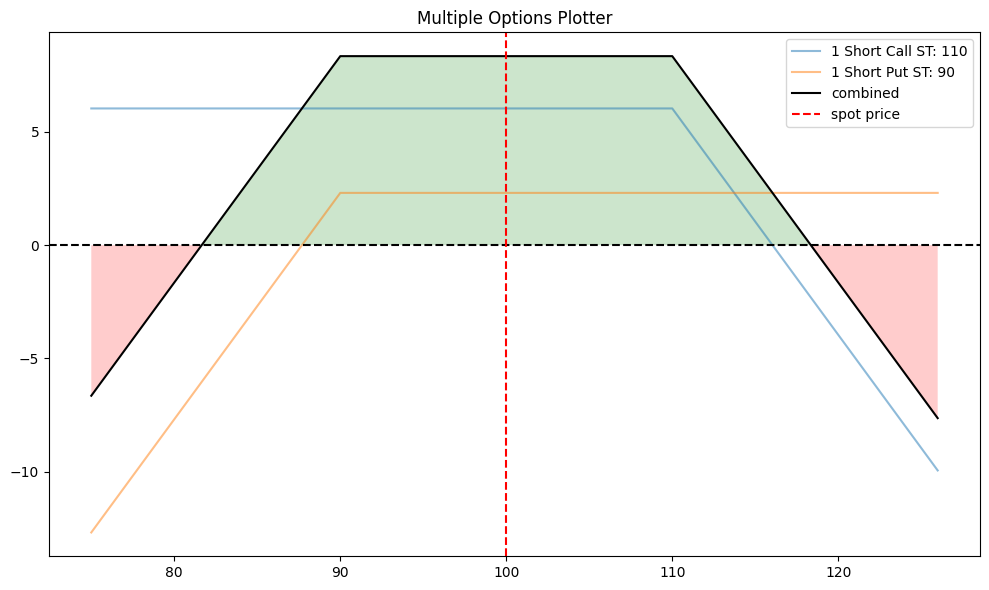

In [13]:
# plot
op_list3 = [op_5, op_6]
op.multi_plotter(spot=leg1.spot, spot_range=25, op_list=op_list3)

In [14]:
# Ironfly
leg1 = BS(100,100,0.05,1,0.2)
leg2 = BS(100,90,0.05,1,0.2)
leg3 = BS(100,110,0.05,1,0.2)

op_1 = {'op_type': 'c', 'strike':leg1.strike, 'tr_type': 's', 'op_pr': leg1.callPrice}
op_2 = {'op_type': 'p', 'strike':leg1.strike, 'tr_type': 's', 'op_pr': leg1.putPrice}
op_3 = {'op_type': 'p', 'strike':leg2.strike, 'tr_type': 'b', 'op_pr': leg2.putPrice}
op_4 = {'op_type': 'c', 'strike':leg3.strike, 'tr_type': 'b', 'op_pr': leg3.callPrice}

In [15]:
#Net cash positions on the ironfly/iron condor
leg1.callPrice + leg1.putPrice - leg2.putPrice - leg3.callPrice

7.673924851238031

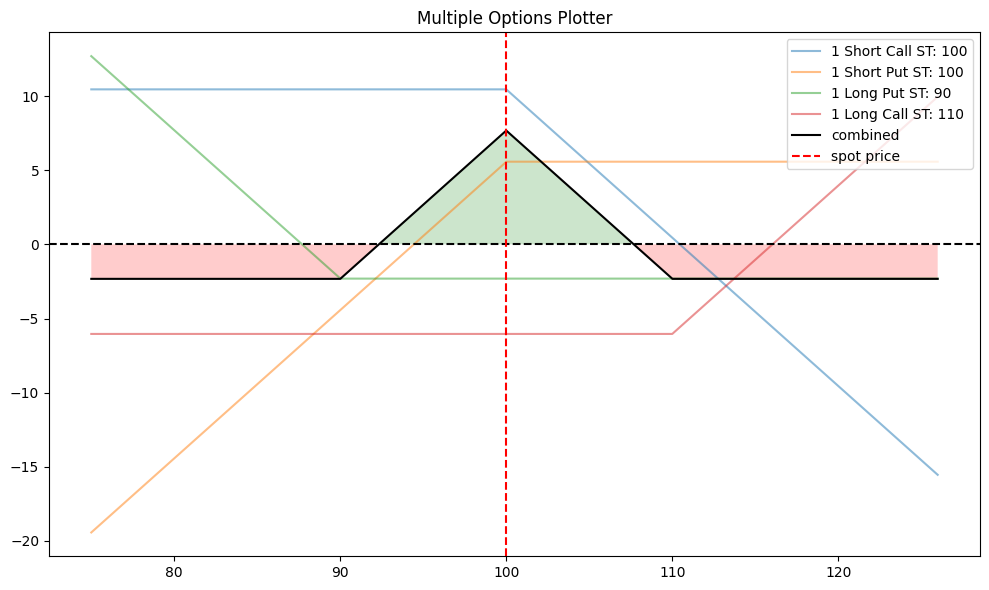

In [16]:
op_list = [op_1, op_2, op_3, op_4]
op.multi_plotter(spot=100, spot_range=25, op_list=op_list)


## SPY Option<a href="#SPY-Option" class="anchor-link"></a>

Let's now retrieve SPY option price from Yahoo Finance using `yfinance` library and manipulate the dataframe using the above Black Scholes option pricing model that we created.
<https://finance.yahoo.com/quote/SPY/options?date=1711584000>

In [17]:
# Get SPY option chain
spy = yf.Ticker('SPY')
options = spy.option_chain('2024-04-26')

In [18]:
from datetime import datetime
dte = (datetime(2024, 4, 19) - datetime.today()).days/365
dte

0.010958904109589041

In [19]:
# April 2024 512 SPY call option price
spot = 515; strike = 515; rate = 0.055; dte = dte; vol = 0.1248

spy_opt = BS(spot,strike,rate,dte,vol)
print(f'Option Price of SPY with BS Model is {spy_opt.callPrice:0.4f}')

Option Price of SPY with BS Model is 2.8414


In [20]:
# Verify the options output
options.calls.head(5)

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY240426C00400000,2024-04-12 16:44:36+00:00,400.0,111.66,111.77,112.19,-8.609993,-7.158886,1.0,63,0.754885,True,REGULAR,USD
1,SPY240426C00405000,2024-03-19 14:48:54+00:00,405.0,110.20,106.79,107.21,0.000000,0.000000,2.0,0,0.725589,True,REGULAR,USD
2,SPY240426C00410000,2024-04-12 15:30:48+00:00,410.0,104.53,101.81,102.25,0.000000,0.000000,3.0,3,0.697269,True,REGULAR,USD
3,SPY240426C00415000,2024-04-11 19:24:49+00:00,415.0,104.76,96.83,97.25,0.000000,0.000000,2.0,3,0.666507,True,REGULAR,USD
4,SPY240426C00420000,2024-03-26 17:59:36+00:00,420.0,103.05,91.86,92.28,0.000000,0.000000,4.0,2,0.638187,True,REGULAR,USD


In [21]:
# Filter calls for strike at or above 450 and less than 600
df = options.calls[(options.calls['strike']>=450) & (options.calls['strike']<=600)]
df.reset_index(drop=True, inplace=True)

# Dataframe manipulation with selected fields
df = pd.DataFrame({'Strike': df['strike'], 
                    'Price': df['lastPrice'], 
                    'ImpVol': df['impliedVolatility']})

# Derive greeks and assign to dataframe as columns
df['Delta'] = df['Gamma'] = df['Vega'] = df['Theta'] = 0.

for i in range(len(df)):
    opt = BS(spot,df['Strike'].iloc[i],rate,dte,df['ImpVol'].iloc[i])
    
    df['Delta'].iloc[i] = opt.callDelta
    df['Gamma'].iloc[i] = opt.gamma
    df['Vega'].iloc[i] = opt.vega
    df['Theta'].iloc[i] = opt.callTheta

# Check output
df.head(5)

,Strike,Price,ImpVol,Delta,Gamma,Vega,Theta
0,450.0,60.90,0.479009,0.996811,0.000374,0.005212,-0.098721
1,455.0,64.20,0.448736,0.996243,0.000463,0.006038,-0.102091
2,460.0,51.83,0.418951,0.995484,0.000585,0.007119,-0.106201
3,465.0,45.80,0.389777,0.994428,0.000758,0.008585,-0.111415
4,470.0,42.09,0.360114,0.993058,0.000996,0.010429,-0.117180


### Visualize Data<a href="#Visualize-Data" class="anchor-link"></a>

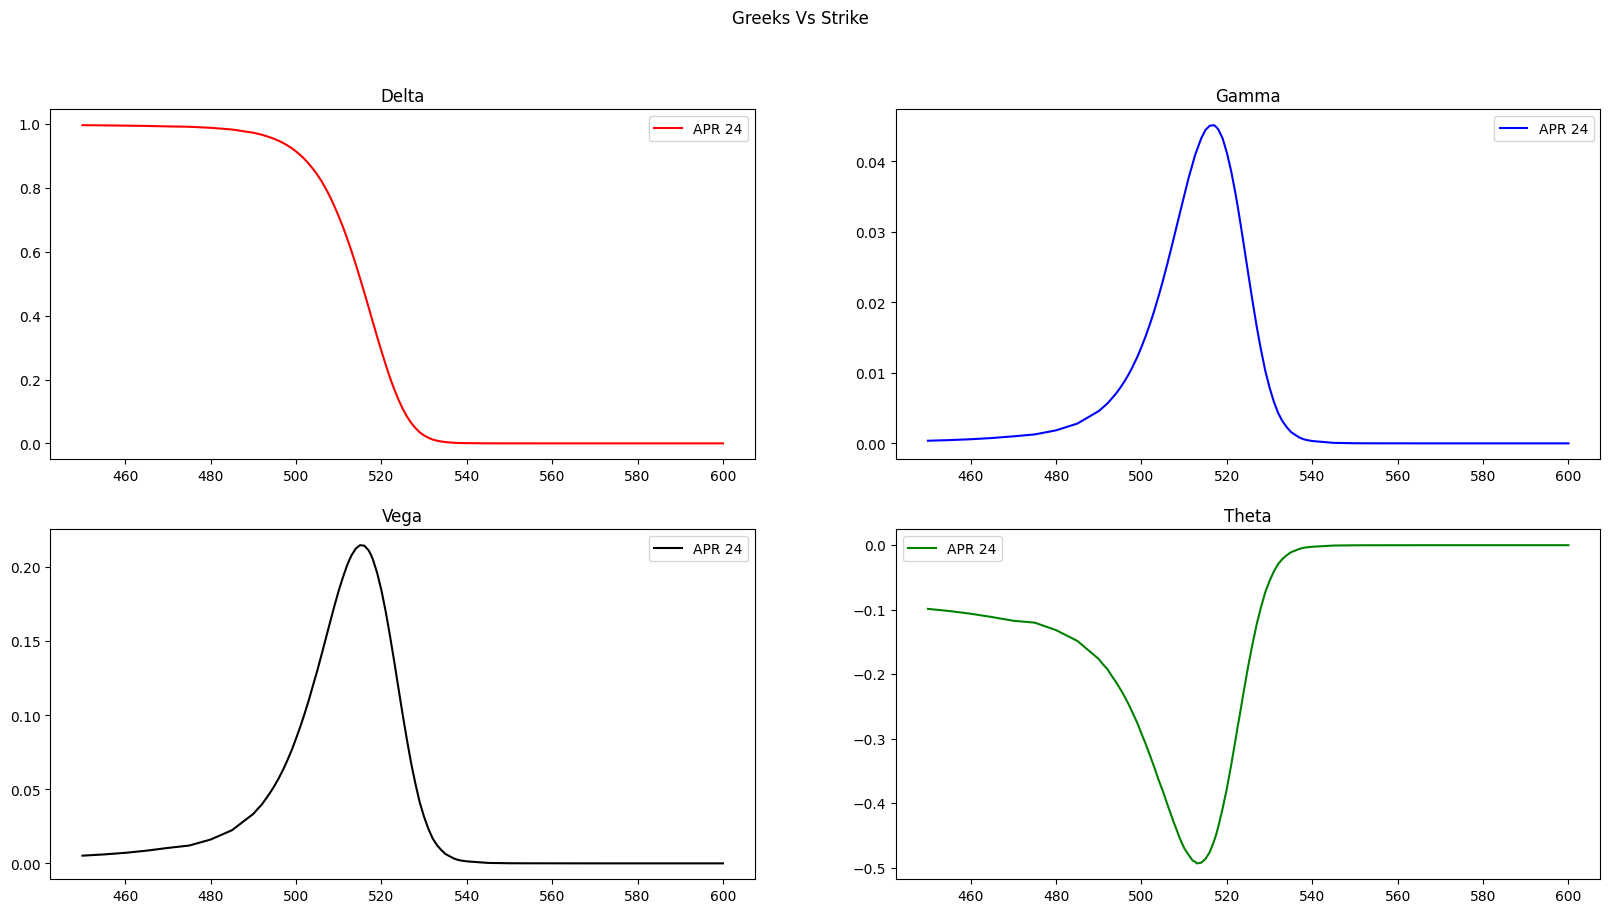

In [22]:
# Plot graph iteratively
fig, ax = plt.subplots(2,2, figsize=(20,10))

ax[0,0].plot(df['Strike'], df['Delta'], color='r', label='APR 24')
ax[0,1].plot(df['Strike'], df['Gamma'], color='b', label='APR 24')
ax[1,0].plot(df['Strike'], df['Vega'],  color='k', label='APR 24')
ax[1,1].plot(df['Strike'], df['Theta'], color='g', label='APR 24')
    
# Set axis title
ax[0,0].set_title('Delta'), ax[0,1].set_title('Gamma'), ax[1,0].set_title('Vega'), ax[1,1].set_title('Theta')

# Define legend
ax[0,0].legend(), ax[0,1].legend(), ax[1,0].legend(), ax[1,1].legend()

# Set title
fig.suptitle('Greeks Vs Strike')

plt.show()

In [23]:
# spy straddle
spy_options = BS(512,512,0.055,0.022,0.1326)

op_1 = {'op_type': 'c', 'strike':spy_options.strike, 'tr_type': 's', 'op_pr': spy_options.callPrice}
op_2 = {'op_type': 'p', 'strike':spy_options.strike, 'tr_type': 's', 'op_pr': spy_options.putPrice}

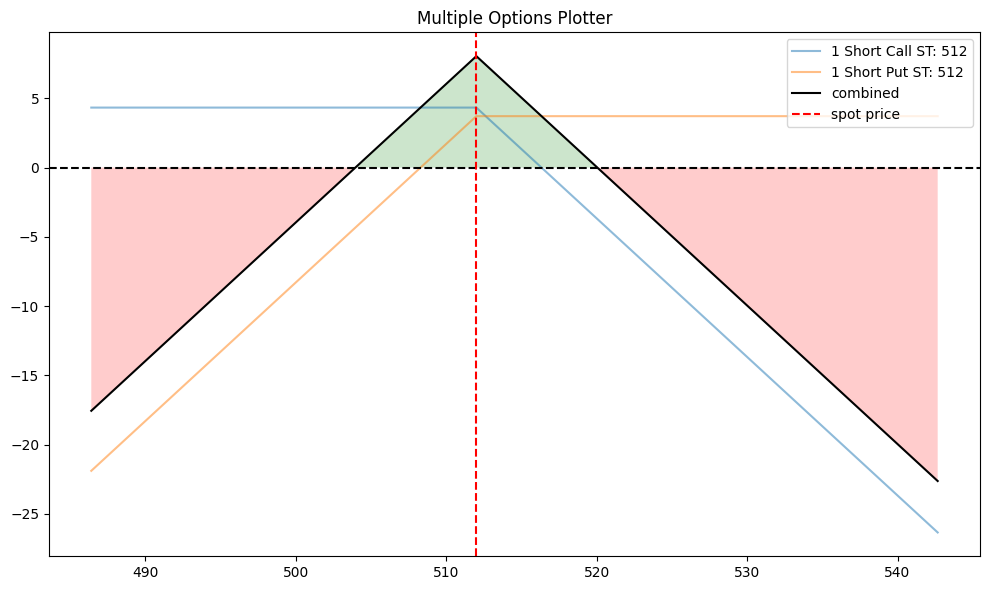

In [24]:
# plot spy straddle
op_list = [op_1, op_2]
op.multi_plotter(spot=spy_options.spot, spot_range=5, op_list=op_list)

In [25]:
# spy straddle
spy_options_leg1 = BS(515,520,0.555,0.022,0.1456)
spy_options_leg2 = BS(515,510,0.0025,0.022,0.124168)

op_7 = {'op_type': 'c', 'strike':spy_options_leg1.strike, 'tr_type': 's', 'op_pr': spy_options_leg1.callPrice}
op_8 = {'op_type': 'p', 'strike':spy_options_leg2.strike, 'tr_type': 's', 'op_pr': spy_options_leg2.putPrice}

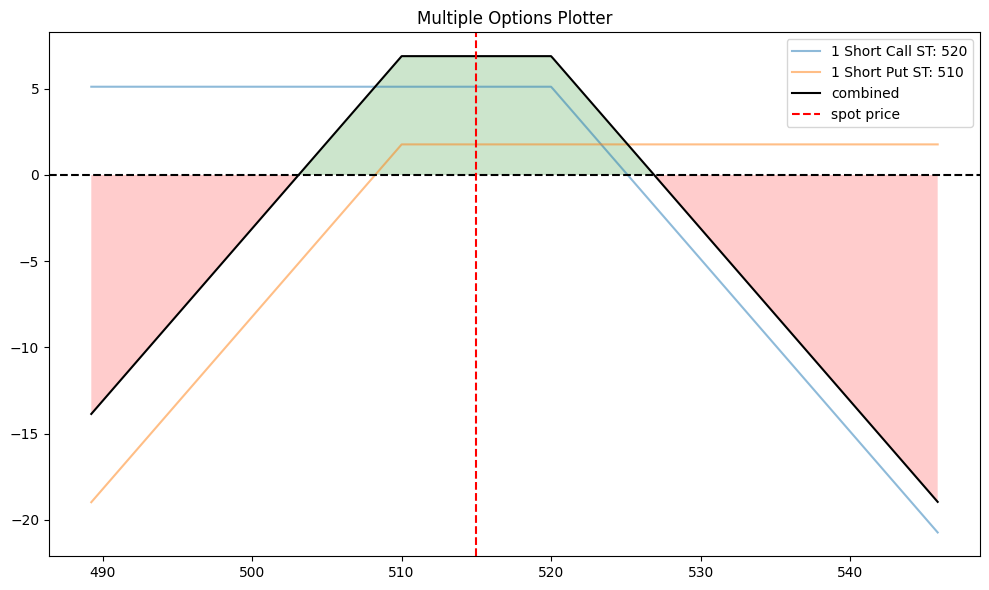

In [26]:
# plot spy straddle
op_list = [op_7, op_8]
op.multi_plotter(spot=spy_options_leg1.spot, spot_range=5, op_list=op_list)

In [27]:
#Greeks for the Straddle
spy_options.callDelta + spy_options.putDelta

0.05688548345874467

In [28]:
spot_range = np.linspace(500,550)
sdelta = []
sgamma = []
svega = []
stheta = []
for i in spot_range:
    opt2 = BS(i,515,rate,dte,.1326)
    sdelta.append(opt2.callDelta+opt2.putDelta)
    sgamma.append(opt2.gamma)
    svega.append(opt2.vega)
    stheta.append(opt2.callTheta + opt2.putTheta)

df2 = pd.DataFrame(
    {'spySpots': spot_range,
     'spy515Delta': sdelta,
     'spy515FGamma': sgamma,
     'spy515Vega': svega,
     'spy515Theta': stheta,
    })
df2

,spySpots,spy515Delta,spy515FGamma,spy515Vega,spy515Theta
0,500.000000,-0.962387,6.620714e-03,0.024052,-0.004997
1,501.020408,-0.946663,8.870488e-03,0.032357,-0.033713
2,502.040816,-0.925837,1.162498e-02,0.042578,-0.069168
3,503.061224,-0.898856,1.490379e-02,0.054809,-0.111757
4,504.081633,-0.864656,1.869471e-02,0.069029,-0.161493
5,505.102041,-0.822237,2.294643e-02,0.085071,-0.217899
6,506.122449,-0.770747,2.756402e-02,0.102604,-0.279943
7,507.142857,-0.709576,3.240839e-02,0.121124,-0.346005
8,508.163265,-0.638435,3.730056e-02,0.139969,-0.413921
9,509.183673,-0.557438,4.203121e-02,0.158355,-0.481078


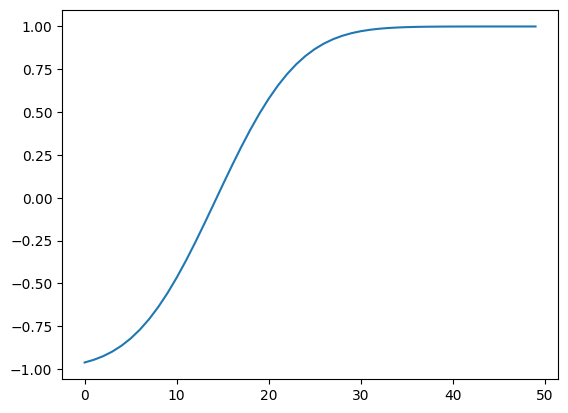

In [29]:
plt.plot(sdelta);

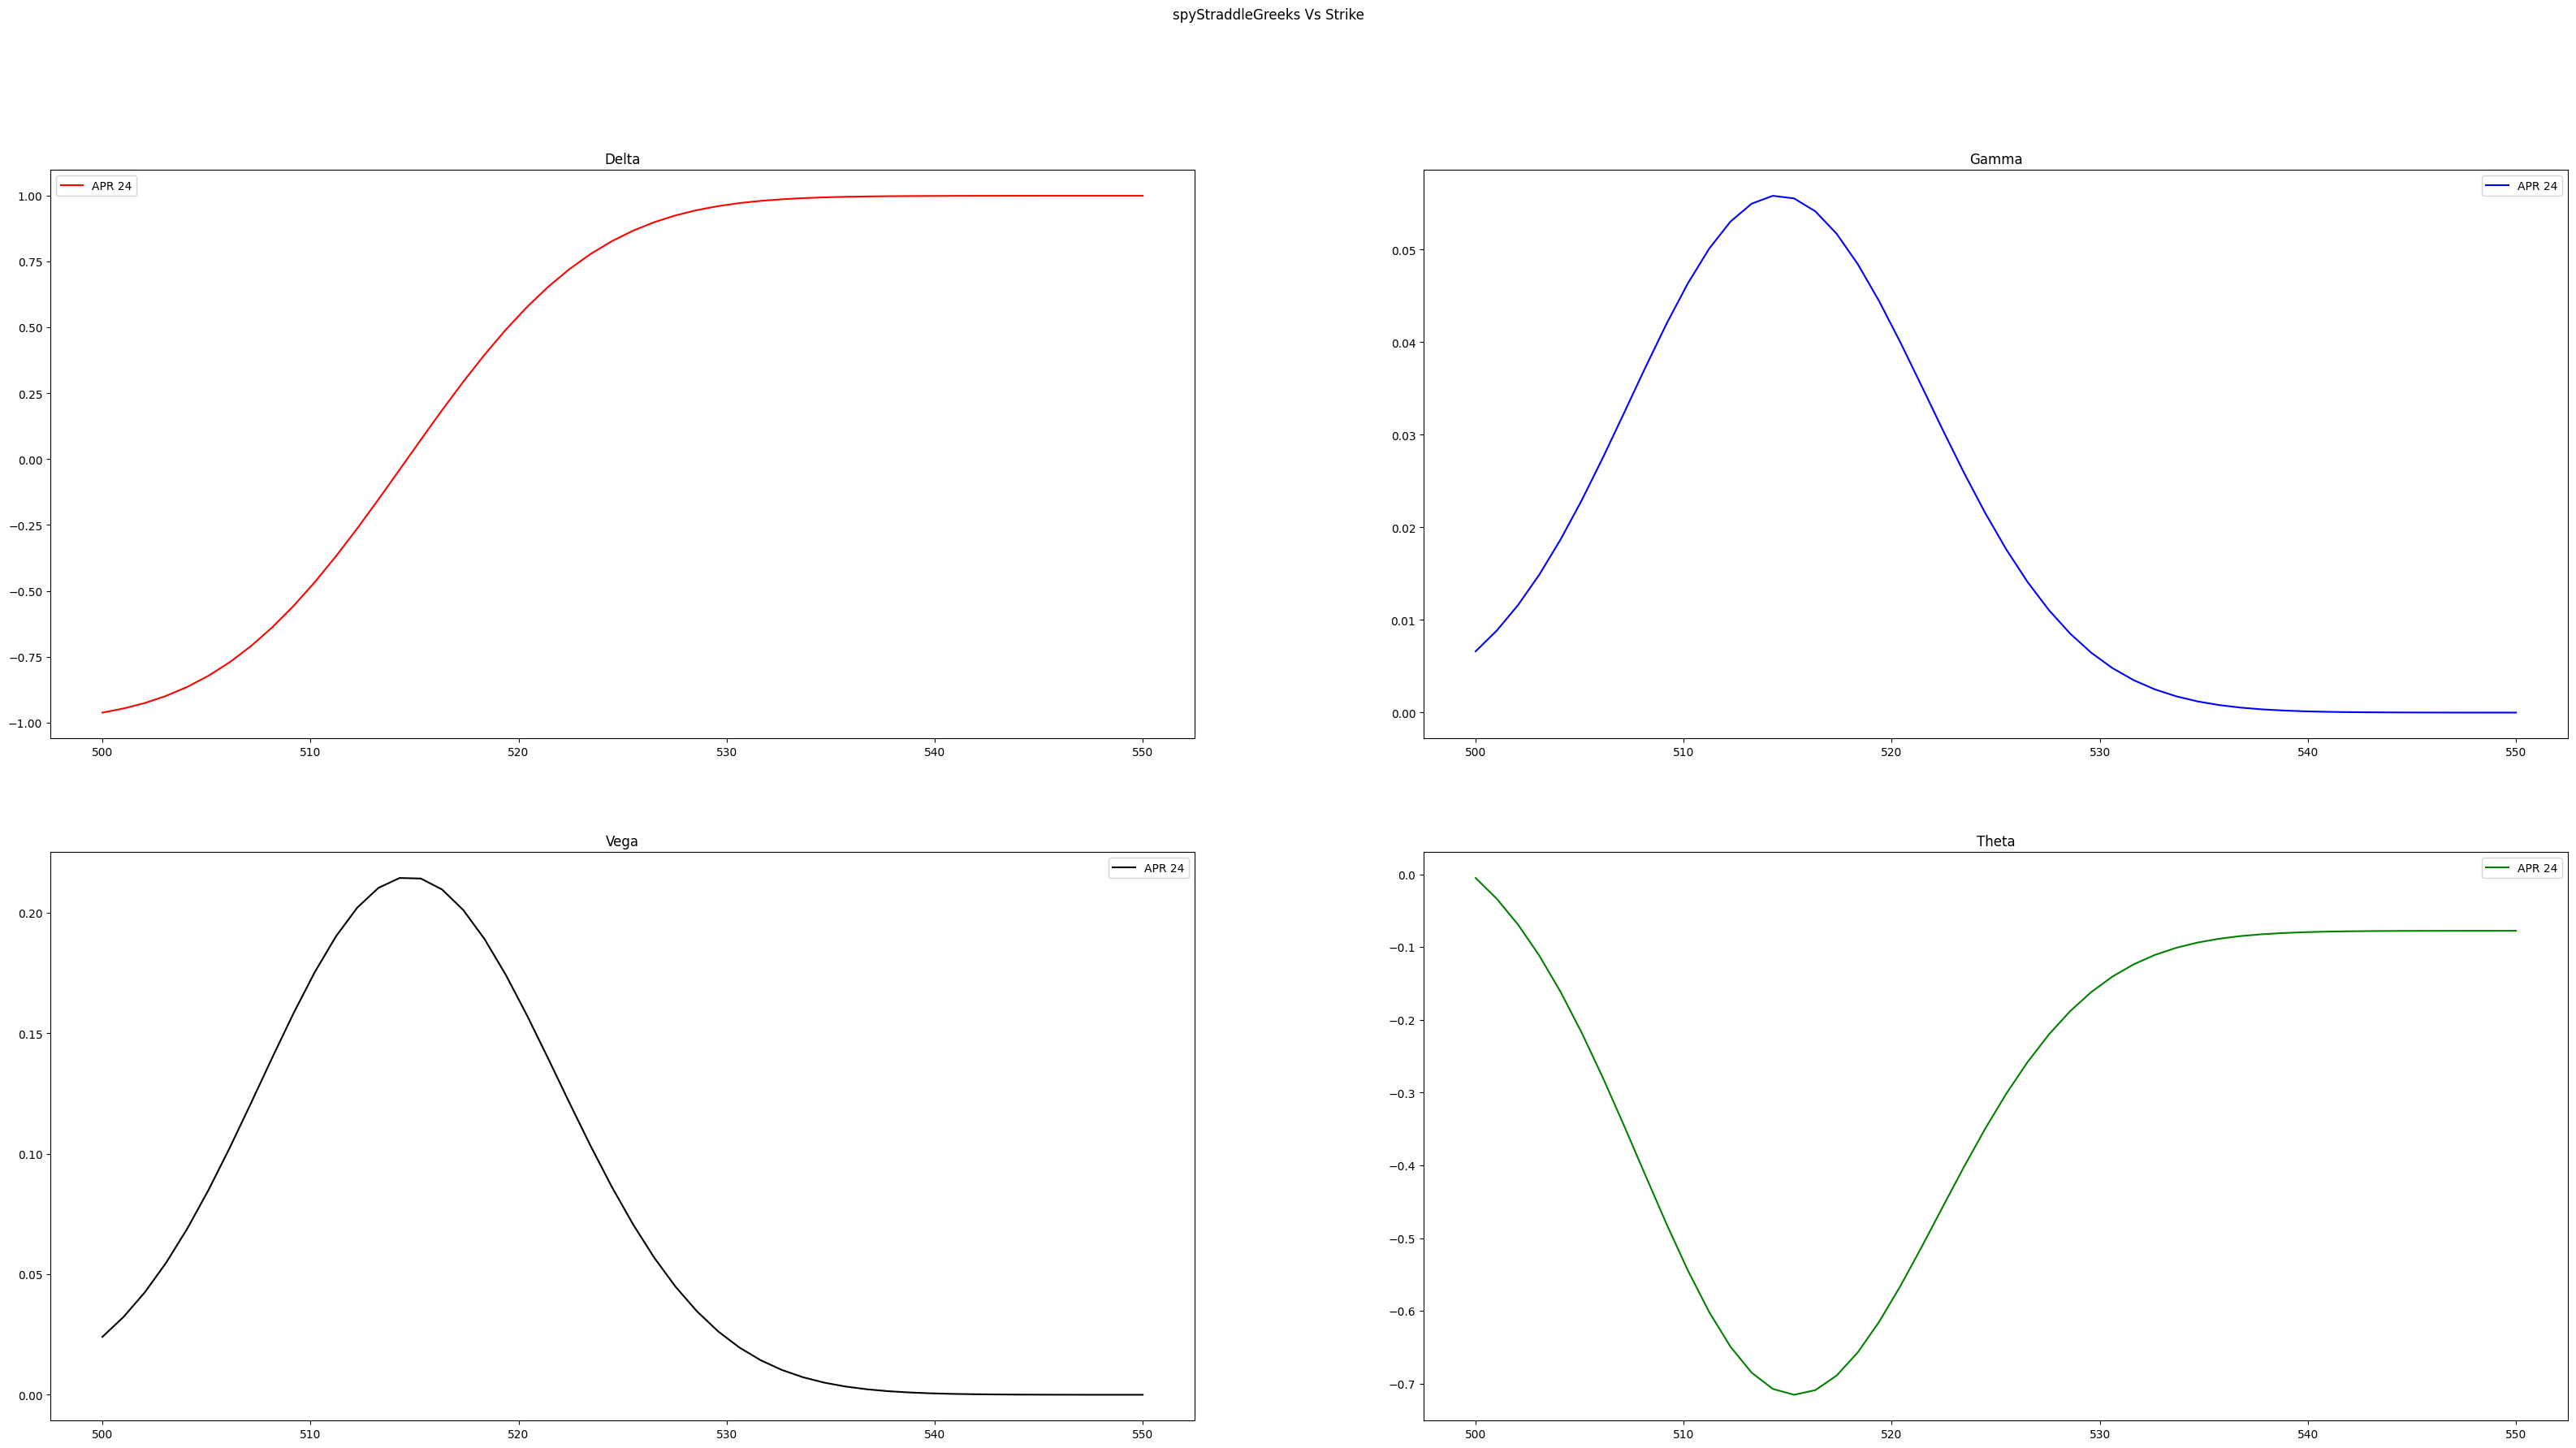

In [30]:
# Plot graph iteratively
fig2, ax = plt.subplots(2,2, figsize=(40,20))

ax[0,0].plot(df2['spySpots'], df2['spy515Delta'], color='r', label='APR 24')
ax[0,1].plot(df2['spySpots'], df2['spy515FGamma'], color='b', label='APR 24')
ax[1,0].plot(df2['spySpots'], df2['spy515Vega'],  color='k', label='APR 24')
ax[1,1].plot(df2['spySpots'], df2['spy515Theta'], color='g', label='APR 24')
    
# Set axis title
ax[0,0].set_title('Delta'), ax[0,1].set_title('Gamma'), ax[1,0].set_title('Vega'), ax[1,1].set_title('Theta')

# Define legend
ax[0,0].legend(), ax[0,1].legend(), ax[1,0].legend(), ax[1,1].legend()

# Set title
fig2.suptitle('spyStraddleGreeks Vs Strike')

plt.show()

In [ ]:
#YT Val of demonstration of Delta Hedging

In [47]:
quP = [10, 10.56, 7.99, 9.66, 13.16]
ttm = np.linspace(1,0,5)
quPDeltas = []
quPPrice = []
CFs = []
for i in range(len(quP)):
    stck = BS(quP[i],10,0.05,ttm[i],.4)
    quPDeltas.append(round(stck.callDelta,3))
    quPPrice.append(round(stck.callPrice,3))

for j in range(len(quPPrice)):
    CFs.append(round(quPPrice[j]*np.exp((0.05*ttm[j])),3))
print(quPDeltas)
print(quPPrice)
print(CFs)

[0.627, 0.67, 0.287, 0.496, 1.0]
[1.802, 1.9, 0.352, 0.675, 3.16]
[1.894, 1.973, 0.361, 0.683, 3.16]


In [48]:
ttl = np.linspace(1,0,5)
ttl

array([1.  , 0.75, 0.5 , 0.25, 0.  ])

In [80]:
np.random.seed()
ranNum = (np.random.standard_normal(10))
pricePa = [10]
for i in range(4):
    S = pricePa[i] * (1+ 0.05*ttm[i+1] + .4 * np.sqrt(ttm[i+1])*ranNum[i])
    pricePa.append(S)
pricePa

[10,
 8.521079711413147,
 11.49323356492969,
 10.39602210581227,
 10.39602210581227]